<a href="https://colab.research.google.com/github/Flurbs222/NumericalAnalysis-Projects/blob/main/Project_4-DataCompression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project 4 - Linear Algebra and Data Compression

Linear algebra provides many powerful and exciting applications. Examples include:
<ul>
    <li>Face recognition via Eigenface;</li>
    <li>Data compression using Singular Value Decomposition;</li>
    <li>JPEG/MPEG compression via discrete cosine transform;</li>
    <li>Signal/sound compression via Fourier series.</li>
</ul>

A common feature is that by using techniques from linear algebra, one may find a very nice approximation of given data (in a very big or even infinite-dimensional vector space) in a reasonable small vector space.

In this project, we investigate how to compress continuous sound data by using finitely many numbers.

Sound data is given as a continuous function $f(x)$. If we divide the time interval into reasonably small subintervals, then on each interval, the function $f(x)$ looks like a periodic function, because the sound is a vibration that propagates as an (in general very complicated) wave of pressure and a wave is periodic. From now on, for simplicity, assume that the period of $f(x)$ is $2\pi$ and we will assume that $f \in C[-\pi, \pi]$.

On $C[-\pi, \pi]$, the following formula yields an inner product:
$$\langle g, h\rangle = \frac{1}{\pi}\int_{-\pi}^{\pi}g(x)h(x)dx.$$
Furthermore, we know that the following set is an orthonormal set.
$$\mathcal{T}_n := \{\frac{1}{\sqrt{2}}, \sin x, \cos x, \sin 2x, \cos 2x, \cdots, \sin nx, \cos nx\}$$
Let $W_n$ be the sub vector space of $C[-\pi, \pi]$ spanned by $\mathcal{T}_n$. Then for any $f \in C[-\pi, \pi]$, its best approximation in $W_n$ is given by
$$S_n(x) := \langle f(x), 1\rangle \frac{1}{2} + \sum_{k=1}^n \langle f(x), \cos kx\rangle \cos kx + \sum_{k=1}^n \langle f(x), \sin kx\rangle \sin kx.$$

##### 1. (10 pts) Construct a function **Simpson(f, m)** which evaluates the definite integral $$\int_{-\pi}^{\pi}f(x)dx$$ with $m$ intervals by using the Simpson's rule. Note that $m$ has to be an even number.

In [ ]:
import numpy as np

def Simpson(f, m):

  if m%2 != 0:
    raise ValueError("m has to be an even number")
  a = -np.pi
  b = np.pi
  h = (b-a)/m
  x = np.linspace(a, b, m+1)
  y = f(x)
  integral = (h / 3) * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]))
  return integral

f = lambda x: np.sin(x) + 1
m = 1000

result =  Simpson(f, m)
print(result)


6.283185307179587


##### 2. (10 pts) Create a function **FourierCoeff(f, n)** which returns the list of Fourier coefficients $a_0, a_1, \cdots, a_n$ and $b_1, b_2, \cdots, b_n$ where $a_0 = \langle f(x), 1\rangle$, $a_k = \langle f(x), \cos kx\rangle$ for $k \ge 1$, $b_k = \langle f(x), \sin kx\rangle$. To calculate each coefficient, use the function Simpson(f, m) with $m = 200$. **굵은 텍스트**

In [ ]:
import numpy as np

def FourierCoeff(f,n):
  a = []
  b = []
  m = 200

  #<f,g> = 1/pi * int_{-pi}^{pi} f(x)g(x) dx
  for k in range(n+1):
    if k == 0:
      a.append(float((1/np.pi)*Simpson(f,m)))
    else:
      g = lambda x : f(x)*np.cos(k*x)
      h = lambda x : f(x)*np.sin(k*x)

      a.append(float((1/np.pi)*Simpson(g,m)))
      b.append(float((1/np.pi)*Simpson(h,m)))
  return a, b


f = lambda x: np.sin(x) + 1
n= 5

print(FourierCoeff(f,5))

([2.0000000000000004, -8.733754460384567e-17, 1.1546319456101628e-16, -2.4572936278370137e-16, 9.769962616701379e-17, 6.217248937900877e-17], [1.0000000000000002, 4.9219887425048615e-17, 3.92278802034222e-17, -1.6394293330298146e-16, 3.367676508029642e-17])


##### 3. (10 pts) Create a function **DiscreteFourierCoeff(f, n)** which returns the list of Fourier coefficients $a_0, a_1, \cdots, a_n$ and $b_1, b_2, \cdots, b_n$. We use $m = 100$. Here $a_0 = \langle \mathbf{y}, \phi_0\rangle$, $a_k = \langle \mathbf{y}, \phi_k\rangle$ for $k \ge 1$, $b_k = \langle \mathbf{y}, \psi_k\rangle$. Check the lecture notes for the definition of $\mathbf{y}$, $\phi_k$, and $\psi_k$.

Note that the initial data is a continuous function, but the approximation is recorded as a list of $2n+1$ numbers!

In [ ]:
import numpy as np

def DiscreteFourierCoeff(f,n):
  a = []
  b = []
  #step 1: fix m
  m = 100
  #step2: choose 2m points in [-π, π) (evenly spaced)
  #x_j = -π + (j * π)/m,     for j = 0, 1, ..., 2m-1
  N = 2 * m
  x = np.linspace(-np.pi, np.pi, N, endpoint=False)

  #step 3: f(x) -> y := (f(x_0),f(x_1), ..., f(x_(2m-1))
  y = f(x)

  #step 4: <f,g> = 1/m * (sum j=0 2m-1) (v_j w_j)
  for k in range(n+1):
    if k == 0:
      a.append(float((1 / m) * np.sum(y)))
    else:
      #step 3 contd: phi and psi
      phi_kx = np.cos(k * x)
      psi_kx = np.sin(k * x)

      ak = (1 / m) * np.sum(y * phi_kx)
      bk = (1 / m) * np.sum(y * psi_kx)

      a.append(float(ak))
      b.append(float(bk))

  return a, b

f = lambda x: np.sin(x) + 1
n= 5

print(DiscreteFourierCoeff(f,5))

([2.0, -7.993605777301127e-17, 1.4210854715202004e-16, -2.042810365310288e-16, 9.325873406851315e-17, 2.6645352591003756e-17], [1.0, 8.659739592076221e-17, 7.105427357601002e-17, -1.4876988529977099e-16, 3.552713678800501e-17])


##### 4. (10 pts) Create a function **FourierApprox(f)** which plots the graphs of $f(x)$ and the graph of continuous Fourier approximation $S_n(x)$ with $n = 2, 5, 10$ on the same plane (with different color). Test your FourierApprox(f) with $f(x) = \cosh(x)$ and $f(x) = \sqrt{\pi^2-x^2}$. Run the function with your favorite $f(x)$, too. Test your function with $f(x) = e^x$ as well. (Note that this one is continuous on $[-\pi, \pi]$, but does not continuously extend to $\mathbb{R}$ because $f(-\pi) \ne f(\pi)$. To get a 'periodic' continuous function $f(x)$ defined on $\mathbb{R}$, $f(-\pi) = f(\pi)$. See what happens near two boundary points.)

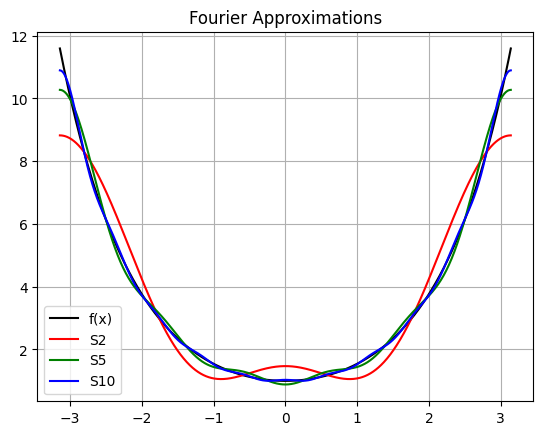

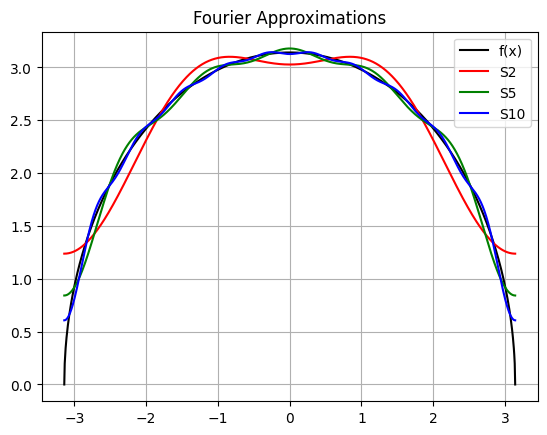

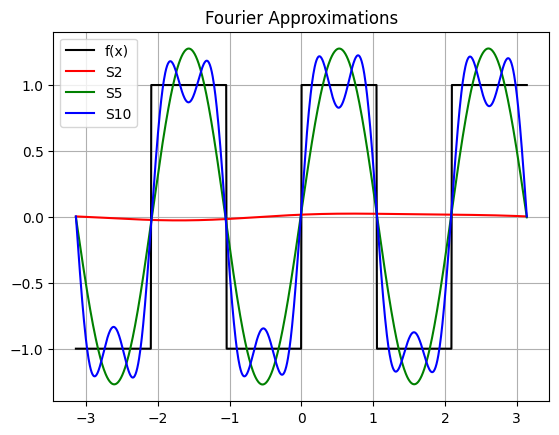

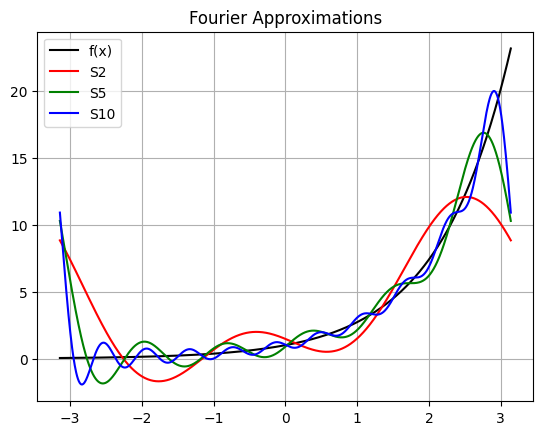

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def FourierApprox(f):
    x = np.linspace(-np.pi, np.pi, 1000)
    y = f(x)

    a, b = FourierCoeff(f, 10)


    plt.plot(x, y,'black', label='f(x)')

    S2 = [a[0]/2] * len(x)
    for k in range(1, 3):
        S2 += a[k]*np.cos(k*x) + b[k-1]*np.sin(k*x)
    plt.plot(x, S2, 'red', label='S2')


    S5 = [a[0]/2] * len(x)
    for k in range(1, 6):
        S5 += a[k]*np.cos(k*x) + b[k-1]*np.sin(k*x)
    plt.plot(x, S5, 'green', label='S5')

    S10 = [a[0]/2] * len(x)
    for k in range(1, 11):
        S10 += a[k]*np.cos(k*x) + b[k-1]*np.sin(k*x)
    plt.plot(x, S10, 'blue', label='S10')

    plt.title("Fourier Approximations")
    plt.legend()
    plt.grid(True)
    plt.show()


FourierApprox(lambda x: np.cosh(x))
FourierApprox(lambda x: np.sqrt(np.pi**2 - x**2))
FourierApprox(lambda x: np.sign(np.sin(x*3))) #not my favorite func, but it looks inersting w/ FourierApprox
FourierApprox(lambda x: np.exp(x))

5. (10 pts) The data below is a sample of a soundwave for a short period of time. For simplicity, assume that the time interval is $[-\pi, \pi]$, and the sample with length $2m = 200$ is obtained by taking evenly spaced time intervals. So $x_0 = -\pi$, $x_1 = -\pi + \frac{1}{100}\pi$, $x_2 = -\pi + \frac{2}{100}\pi$, $\cdots$. Create a function **DiscreteFourierApprox(y)** which plots the sample data $\mathbf{y}$ and the graph of discrete Fourier approximation $S_n(x)$ with $n = 2, 5, 10$ on the same plane.

In [ ]:
y=[-7.17825413156567,-7.1793701412743,-7.16733849160952,-7.13806099877736,-7.08753543897104,-7.0119731343661,-6.90791086656375,-6.7723143655052,-6.6026708521166,-6.39706840356452,-6.15426025346228,-5.87371252685991,-5.55563433152807,-5.20098957226975,-4.81149031259588,-4.38957196666856,-3.93835105256917,-3.46156666462669,-2.96350721727113,-2.44892436603452,-1.92293631436397,-1.39092296058753,-0.858415521897378,-0.330983387404726,0.185879002302009,0.686862476823865,1.16694798121946,1.62150342860695,2.04637026745253,2.4379377507971,2.79320322347624,3.10981711252415,3.38611170586787,3.62111322482392,3.81453712603986,3.96676699740945,4.07881782923126,4.15228483592808,4.18927936505413,4.19235375000885,4.1644172328551,4.10864529719514,4.02838490293486,3.92705820128905,3.8080673275458,3.67470282063315,3.5300581038571,3.37695228343203,3.21786328533368,3.05487306278144,2.88962627383662,2.7233034598531,2.55660936041168,2.38977658915586,2.22258447827461,2.05439248803604,1.88418718241784,1.71064140274916,1.53218393795494,1.34707770114348,1.15350418544073,0.949651793363313,0.733805518371333,0.504435407680138,0.260281253383451,0.00043104416958693,-0.275609139599575,-0.567855892600087,-0.875801749786061,-1.19838246884653,-1.53395948887067,-1.88031833194498,-2.23468329950084,-2.59374838823281,-2.95372392220828,-3.31039797935009,-3.65921129255264,-3.9953439385711,-4.3138118010466,-4.60957051616217,-4.87762438783055,-5.11313759997417,-5.31154496080349,-5.46865939080727,-5.58077341347654,-5.64475202486102,-5.65811450241788,-5.61910296106695,-5.52673576912185,-5.38084429156528,-5.18209182442877,-4.93197401219301,-4.63280048966559,-4.28765794965145,-3.9003552965237,-3.47535199210909,-3.01767112295422,-2.53279910638992,-2.02657429701372,-1.50506704645213,-0.974454,-0.44088957787058,0.0896223181513085,0.611353312630683,1.11896927449907,1.60763987011297,2.07313627689645,2.51191465040037,2.92118326546001,3.29895163288898,3.64406031782336,3.9561906443194,4.23585395212723,4.48436056411675,4.70376911469609,4.89681736877206,5.06683611564488,5.21764814153265,5.35345465782678,5.4787118803975,5.59800071031138,5.71589265169831,5.83681521338724,5.96492007427387,6.10395724701381,6.25715835127125,6.42713190900982,6.61577330462839,6.82419171829347,7.05265594935557,7.30056060741856,7.56641367179835,7.84784591703997,8.14164218480438,8.44379396311453,8.74957222507196,9.05361899291466,9.35005564136536,9.63260554750755,9.89472834275533,10.12976273439,10.3310746466534,10.4922072898708,10.6070297040784,10.6698803427985,10.6757023626674,10.6201674633504,10.4997853754798,10.3119964163468,10.0552449162263,9.72903175352977,9.33394471420792,8.87166589871425,8.34495592640278,7.75761522002221,7.11442317940288,6.42105656106681,5.68398885733906,4.91037290334639,4.10790932281203,3.28470374479894,2.44911597599151,1.60960449085604,0.774569700989817,-0.0478005170560671,-0.849679619491468,-1.62374224545972,-2.36329206555511,-3.06237486423341,-3.71587444498204,-4.31958935554704,-4.87028888421989,-5.36574726627127,-5.80475555039019,-6.18711109624707,-6.51358519363048,-6.78586979867676,-7.00650486156638,-7.17878816141456,-7.30666995758652,-7.39463510315462,-7.44757553792188,-7.47065627918407,-7.46917815374162,-7.44844056198358,-7.41360753341908,-7.36958022399698,-7.32087882196741,-7.27153657572034,-7.22500834046981,-7.18409566882062,-7.15089005243946,-7.12673546860872,-7.11221090753357,-7.10713306561076,-7.11057889840862,-7.12092724677407,-7.13591829186413,-7.15272917097689,-7.16806370593434]

Again, the initial data has 200 samples, but even with small number of coordinates, we already have a very descent approximation.

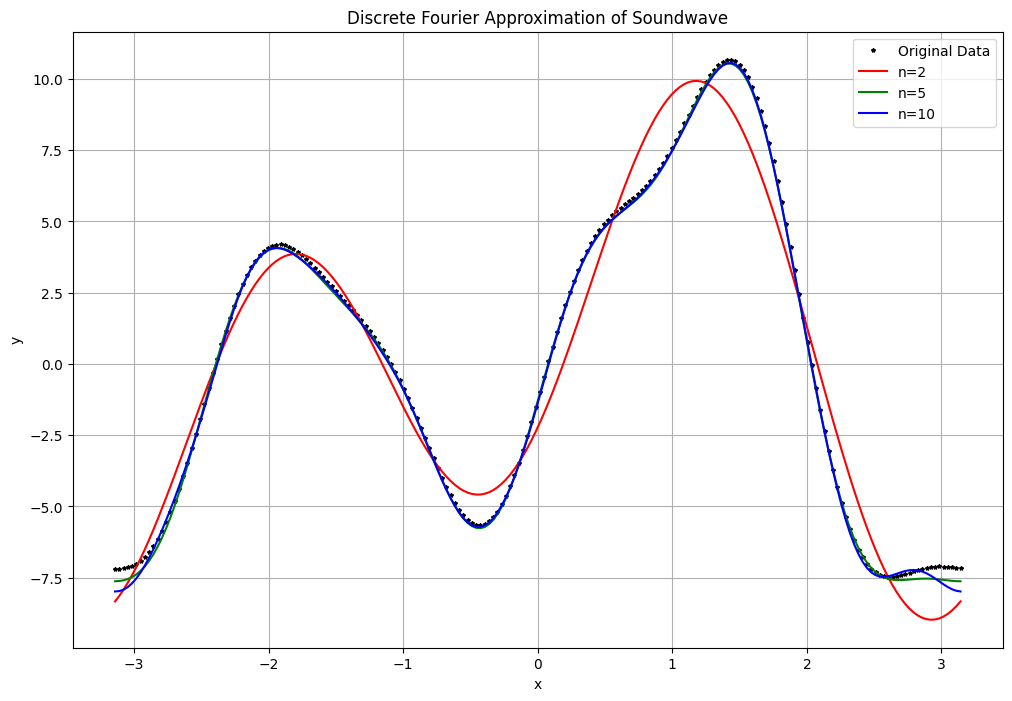

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def DiscreteFourierApprox(y):
    # Length of the sample
    N = len(y)

    # Create evenly spaced x values on [-π, π]
    x = np.linspace(-np.pi, np.pi, N)

    # Compute the discrete Fourier coefficients
    def compute_coefficients(y, n):
        N = len(y)

        # Compute a0 (the constant term)
        a0 = np.sum(y) / N

        # Compute ak and bk for k = 1, 2, ..., n
        a = np.zeros(n+1)
        b = np.zeros(n+1)

        a[0] = a0

        for k in range(1, n+1):
            a[k] = 2.0 / N * np.sum(y * np.cos(k * x))
            b[k] = 2.0 / N * np.sum(y * np.sin(k * x))

        return a, b

    # Function to compute the Fourier approximation
    def fourier_approximation(x_values, a, b, n):
        result = a[0] / 2.0  # Start with a0/2

        for k in range(1, n+1):
            result += a[k] * np.cos(k * x_values) + b[k] * np.sin(k * x_values)

        return result

    # Compute coefficients for n=2, 5, 10
    a2, b2 = compute_coefficients(y, 2)
    a5, b5 = compute_coefficients(y, 5)
    a10, b10 = compute_coefficients(y, 10)

    # Compute approximations
    y2 = fourier_approximation(x, a2, b2, 2)
    y5 = fourier_approximation(x, a5, b5, 5)
    y10 = fourier_approximation(x, a10, b10, 10)

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Plot the original data
    plt.plot(x, y, 'k*', label='Original Data', markersize=3)

    # Plot the Fourier approximations
    plt.plot(x, y2, 'r-', label='n=2', linewidth=1.5)
    plt.plot(x, y5, 'g-', label='n=5', linewidth=1.5)
    plt.plot(x, y10, 'b-', label='n=10', linewidth=1.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Discrete Fourier Approximation of Soundwave')
    plt.legend()
    plt.grid(True)
    plt.show()

y = [-7.17825413156567,-7.1793701412743,-7.16733849160952,-7.13806099877736,-7.08753543897104,-7.0119731343661,-6.90791086656375,-6.7723143655052,-6.6026708521166,-6.39706840356452,-6.15426025346228,-5.87371252685991,-5.55563433152807,-5.20098957226975,-4.81149031259588,-4.38957196666856,-3.93835105256917,-3.46156666462669,-2.96350721727113,-2.44892436603452,-1.92293631436397,-1.39092296058753,-0.858415521897378,-0.330983387404726,0.185879002302009,0.686862476823865,1.16694798121946,1.62150342860695,2.04637026745253,2.4379377507971,2.79320322347624,3.10981711252415,3.38611170586787,3.62111322482392,3.81453712603986,3.96676699740945,4.07881782923126,4.15228483592808,4.18927936505413,4.19235375000885,4.1644172328551,4.10864529719514,4.02838490293486,3.92705820128905,3.8080673275458,3.67470282063315,3.5300581038571,3.37695228343203,3.21786328533368,3.05487306278144,2.88962627383662,2.7233034598531,2.55660936041168,2.38977658915586,2.22258447827461,2.05439248803604,1.88418718241784,1.71064140274916,1.53218393795494,1.34707770114348,1.15350418544073,0.949651793363313,0.733805518371333,0.504435407680138,0.260281253383451,0.00043104416958693,-0.275609139599575,-0.567855892600087,-0.875801749786061,-1.19838246884653,-1.53395948887067,-1.88031833194498,-2.23468329950084,-2.59374838823281,-2.95372392220828,-3.31039797935009,-3.65921129255264,-3.9953439385711,-4.3138118010466,-4.60957051616217,-4.87762438783055,-5.11313759997417,-5.31154496080349,-5.46865939080727,-5.58077341347654,-5.64475202486102,-5.65811450241788,-5.61910296106695,-5.52673576912185,-5.38084429156528,-5.18209182442877,-4.93197401219301,-4.63280048966559,-4.28765794965145,-3.9003552965237,-3.47535199210909,-3.01767112295422,-2.53279910638992,-2.02657429701372,-1.50506704645213,-0.974454,-0.44088957787058,0.0896223181513085,0.611353312630683,1.11896927449907,1.60763987011297,2.07313627689645,2.51191465040037,2.92118326546001,3.29895163288898,3.64406031782336,3.9561906443194,4.23585395212723,4.48436056411675,4.70376911469609,4.89681736877206,5.06683611564488,5.21764814153265,5.35345465782678,5.4787118803975,5.59800071031138,5.71589265169831,5.83681521338724,5.96492007427387,6.10395724701381,6.25715835127125,6.42713190900982,6.61577330462839,6.82419171829347,7.05265594935557,7.30056060741856,7.56641367179835,7.84784591703997,8.14164218480438,8.44379396311453,8.74957222507196,9.05361899291466,9.35005564136536,9.63260554750755,9.89472834275533,10.12976273439,10.3310746466534,10.4922072898708,10.6070297040784,10.6698803427985,10.6757023626674,10.6201674633504,10.4997853754798,10.3119964163468,10.0552449162263,9.72903175352977,9.33394471420792,8.87166589871425,8.34495592640278,7.75761522002221,7.11442317940288,6.42105656106681,5.68398885733906,4.91037290334639,4.10790932281203,3.28470374479894,2.44911597599151,1.60960449085604,0.774569700989817,-0.0478005170560671,-0.849679619491468,-1.62374224545972,-2.36329206555511,-3.06237486423341,-3.71587444498204,-4.31958935554704,-4.87028888421989,-5.36574726627127,-5.80475555039019,-6.18711109624707,-6.51358519363048,-6.78586979867676,-7.00650486156638,-7.17878816141456,-7.30666995758652,-7.39463510315462,-7.44757553792188,-7.47065627918407,-7.46917815374162,-7.44844056198358,-7.41360753341908,-7.36958022399698,-7.32087882196741,-7.27153657572034,-7.22500834046981,-7.18409566882062,-7.15089005243946,-7.12673546860872,-7.11221090753357,-7.10713306561076,-7.11057889840862,-7.12092724677407,-7.13591829186413,-7.15272917097689,-7.16806370593434]
DiscreteFourierApprox(y)